# Часть 1

## Этап 1

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier

from sklift.metrics import qini_auc_score, qini_curve, uplift_at_k, uplift_auc_score, uplift_curve
from sklift.models import SoloModel, TwoModels

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)

DATA_PATH = Path('uplift_fp_data.csv')
df = pd.read_csv(DATA_PATH)

print(f'Размер датасета: {df.shape}')
display(df.head())
print('Пропуски по столбцам:')
display(df.isna().sum().to_frame('missing_count').T)
print('Типы данных:')
display(df.dtypes.to_frame('dtype').T)

if df.isna().sum().sum() == 0:
    print('Пропусков нет, дополнительное заполнение не требуется.')
else:
    numeric_columns = df.select_dtypes(include='number').columns
    df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())
    print('Числовые пропуски заполнены медианами.')


Размер датасета: (64000, 10)


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
0,10,1,142.44,1,0,1,0,1,1,0
1,6,2,329.08,1,1,2,1,2,0,0
2,7,1,180.65,0,1,1,1,2,1,0
3,9,4,675.83,1,0,2,1,2,0,0
4,2,0,45.34,1,0,0,0,2,1,0


Пропуски по столбцам:


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
missing_count,0,0,0,0,0,0,0,0,0,0


Типы данных:


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
dtype,int64,int64,float64,int64,int64,int64,int64,int64,int64,int64


Пропусков нет, дополнительное заполнение не требуется.


## Этап 2

### EDA


,n,conversion_rate,positive_cases
treatment,,,
control,42613,0.144463,6156
treatment,21387,0.151400,3238


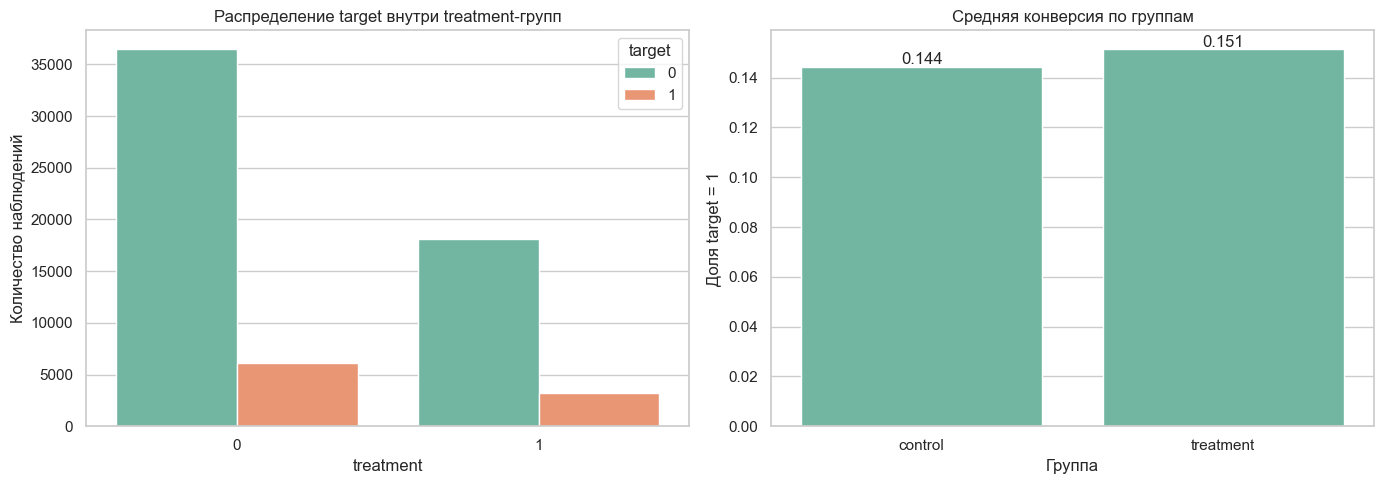

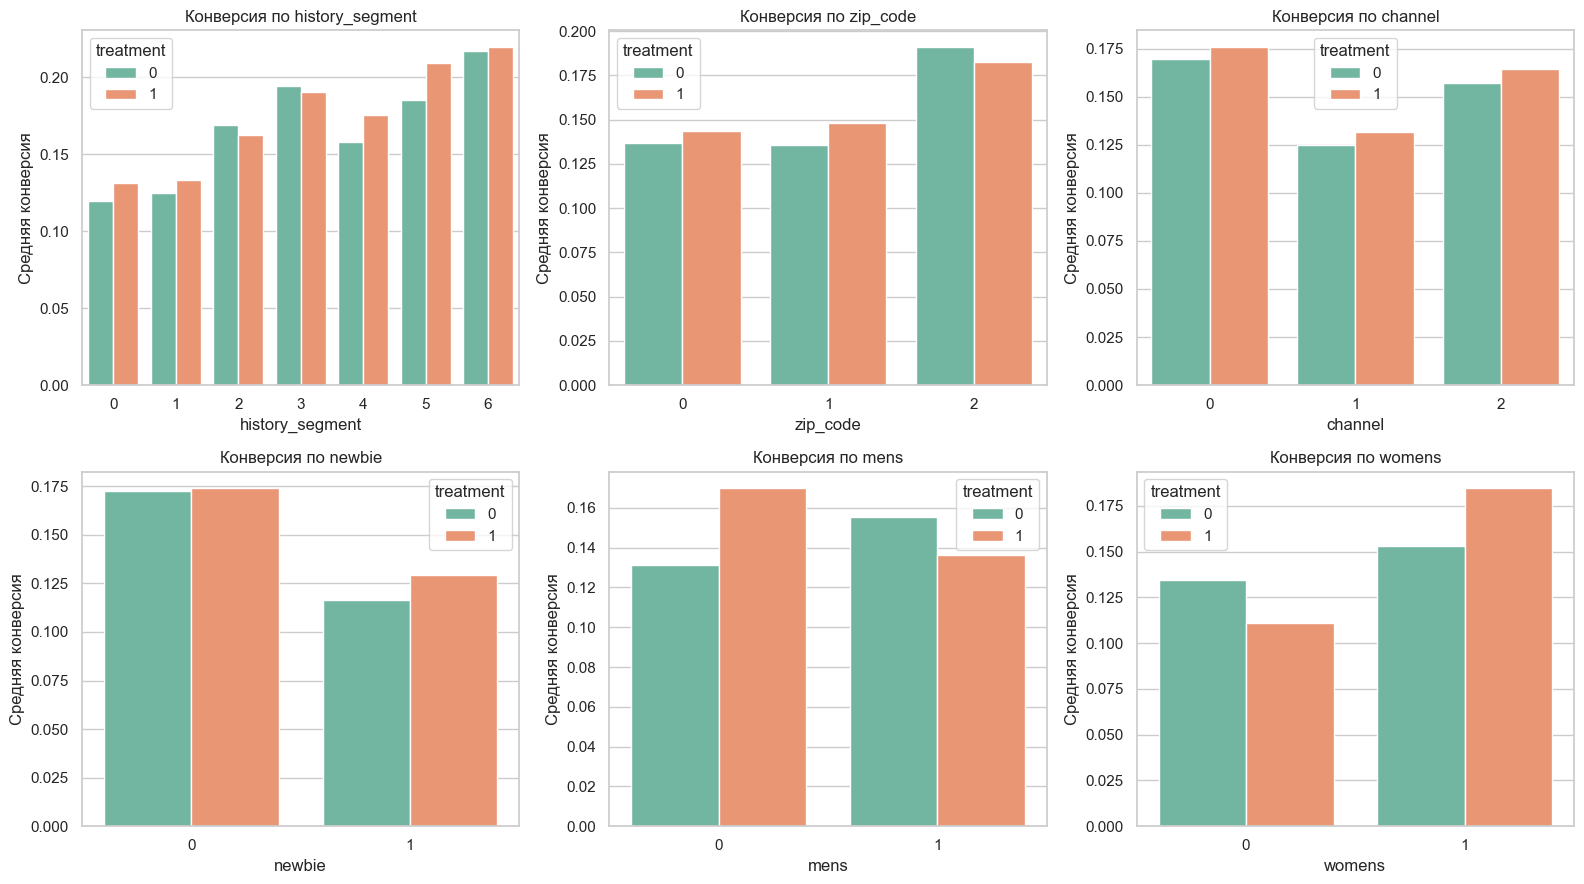

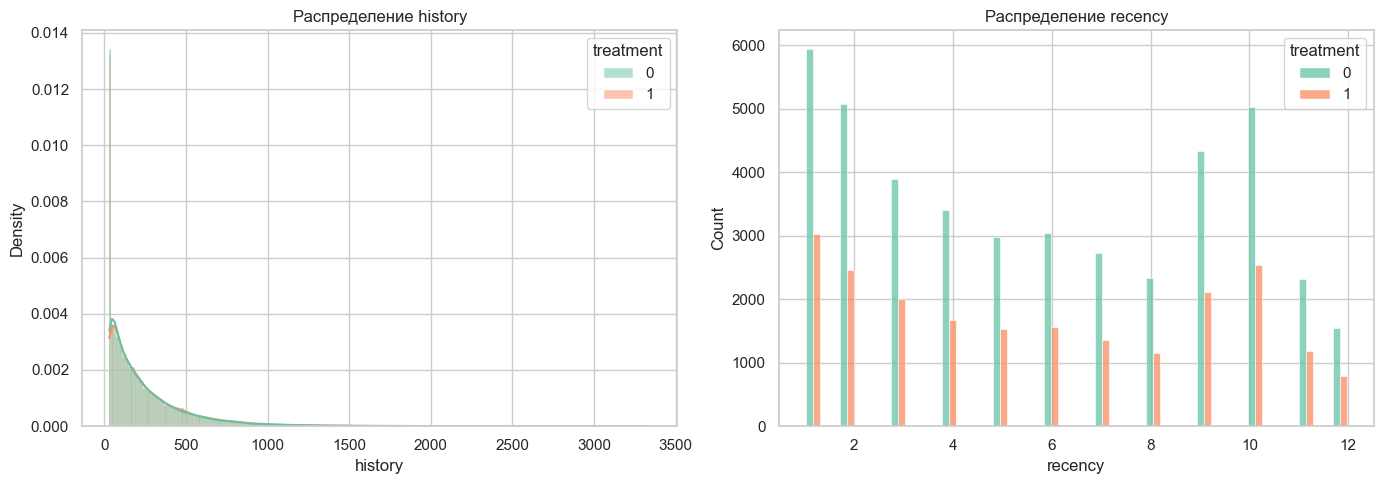

In [2]:
eda_summary = (
    df.groupby('treatment')['target']
      .agg(['count', 'mean', 'sum'])
      .rename(index={0: 'control', 1: 'treatment'}, columns={'count': 'n', 'mean': 'conversion_rate', 'sum': 'positive_cases'})
)
display(eda_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='treatment', hue='target', ax=axes[0])
axes[0].set_title('Распределение target внутри treatment-групп')
axes[0].set_xlabel('treatment')
axes[0].set_ylabel('Количество наблюдений')
axes[0].legend(title='target', labels=['0', '1'])

conversion_plot = eda_summary.reset_index()
conversion_plot['treatment'] = conversion_plot['treatment'].map({'control': 'control', 'treatment': 'treatment'})
sns.barplot(data=conversion_plot, x='treatment', y='conversion_rate', ax=axes[1])
axes[1].set_title('Средняя конверсия по группам')
axes[1].set_xlabel('Группа')
axes[1].set_ylabel('Доля target = 1')
for i, value in enumerate(conversion_plot['conversion_rate']):
    axes[1].text(i, value + 0.001, f'{value:.3f}', ha='center')

plt.tight_layout()
plt.show()

categorical_like = ['history_segment', 'zip_code', 'channel', 'newbie', 'mens', 'womens']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
for ax, col in zip(axes, categorical_like):
    sns.barplot(data=df, x=col, y='target', hue='treatment', estimator=np.mean, errorbar=None, ax=ax)
    ax.set_title(f'Конверсия по {col}')
    ax.set_ylabel('Средняя конверсия')
    ax.legend(title='treatment')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='history', hue='treatment', kde=True, stat='density', common_norm=False, ax=axes[0])
axes[0].set_title('Распределение history')
sns.histplot(data=df, x='recency', hue='treatment', kde=False, multiple='dodge', shrink=0.85, ax=axes[1])
axes[1].set_title('Распределение recency')
plt.tight_layout()
plt.show()


### Выводы по EDA

- Датасет чистый: 64 000 наблюдений, пропуски отсутствуют.
- Контрольная группа больше тестовой: примерно 42.6 тыс. против 21.4 тыс., но обе группы достаточно велики для устойчивой оценки эффекта.
- Базовая конверсия в treatment-группе выше, чем в control, но разница небольшая, поэтому для выбора аудитории нужна именно uplift-модель, а не обычный классификатор отклика.
- Наибольший практический интерес по EDA дают признаки, связанные с давностью и интенсивностью покупок: `recency`, `history`, `history_segment`, а также статус `newbie`.
- По графикам видно, что поведение пользователей неоднородно по каналам и сегментам расходов, значит модель должна уметь ловить разные эффекты воздействия в разных подгруппах пользователей.


# Этап 2

### Проверка на статистическую значимость

### Обоснование выбора статистического теста

Целевая переменная `target` бинарная, а группы `control` и `treatment` независимы. Поэтому для проверки различий между группами корректно использовать **z-тест для сравнения долей**. Он лучше соответствует природе данных, чем t-тест для непрерывных величин.

Дополнительно предпосылки теста выполняются:
- наблюдения независимы;
- объём выборки очень большой в обеих группах;
- ожидаемое число успехов и неуспехов в каждой группе существенно больше 5, поэтому нормальное приближение для долей применимо.

Для полноты ниже я также вывожу Welch t-test и Mann-Whitney: они дают тот же качественный вывод, но основным считаю именно z-тест для долей.


In [3]:
control_target = df.loc[df['treatment'] == 0, 'target']
treatment_target = df.loc[df['treatment'] == 1, 'target']

group_stats = pd.DataFrame({
    'group': ['control', 'treatment'],
    'n_obs': [len(control_target), len(treatment_target)],
    'mean_target': [control_target.mean(), treatment_target.mean()],
    'std_target': [control_target.std(), treatment_target.std()],
    'successes': [control_target.sum(), treatment_target.sum()],
})
display(group_stats)

z_stat, z_pvalue = proportions_ztest(
    count=[treatment_target.sum(), control_target.sum()],
    nobs=[len(treatment_target), len(control_target)]
)
welch_stat, welch_pvalue = stats.ttest_ind(treatment_target, control_target, equal_var=False)
mann_stat, mann_pvalue = stats.mannwhitneyu(treatment_target, control_target, alternative='two-sided')

stat_results = pd.DataFrame({
    'test': ['proportions_ztest', 'welch_ttest', 'mann_whitney_u'],
    'statistic': [z_stat, welch_stat, mann_stat],
    'p_value': [z_pvalue, welch_pvalue, mann_pvalue]
})
display(stat_results)

if z_pvalue < 0.05:
    print(f'Различие между treatment и control статистически значимо: p-value = {z_pvalue:.5f}.')
else:
    print(f'Статистически значимого различия не обнаружено: p-value = {z_pvalue:.5f}.')


,group,n_obs,mean_target,std_target,successes
0,control,42613,0.144463,0.351563,6156
1,treatment,21387,0.151400,0.358447,3238


,test,statistic,p_value
0,proportions_ztest,2.339316e+00,0.019319
1,welch_ttest,2.324383e+00,0.020110
2,mann_whitney_u,4.588434e+08,0.019320


Различие между treatment и control статистически значимо: p-value = 0.01932.


## Построение корреляций

,target,history_segment,history,womens,zip_code,channel,treatment,mens,newbie,recency
target,1.0,0.069734,0.065153,0.051999,0.03757,0.010584,0.009247,0.006712,-0.073924,-0.074765


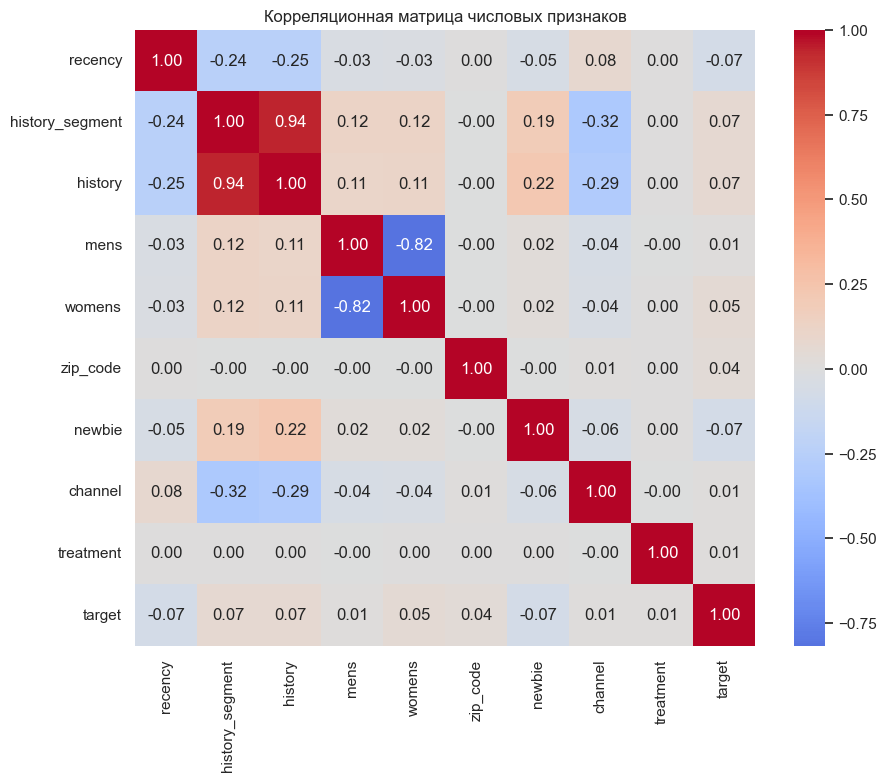

In [4]:
corr_matrix = df.corr(numeric_only=True)

target_corr = corr_matrix[['target']].sort_values('target', ascending=False)
display(target_corr.T)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица числовых признаков')
plt.show()


### Выводы по корреляциям

- Наиболее заметная положительная связь с `target` у `history_segment`, `history` и `womens`, хотя сами коэффициенты умеренные.
- Наиболее заметная отрицательная связь с `target` у `recency` и `newbie`: чем давно пользователь покупал и чем слабее закрепился в сервисе, тем ниже вероятность отклика.
- Между `history_segment` и `history` очень высокая корреляция, поэтому в модели возможна частичная избыточность этих признаков, но для деревьев и CatBoost это не критично.
- Между `mens` и `womens` наблюдается сильная отрицательная связь, что отражает различие покупательских паттернов.
- Корреляция `treatment` с признаками близка к нулю, что выглядит правдоподобно для A/B-эксперимента и косвенно подтверждает корректность рандомизации.


## Этап 3

### Обоснование выбора baseline uplift-модели

В качестве baseline я выбираю **T-learner (`TwoModels`) на базе `CatBoostClassifier`**.

Почему именно этот вариант:
- проект ориентирован на метрику `Uplift@30`, то есть нам важно качественно ранжировать верхние 30% пользователей по ожидаемому инкрементальному эффекту;
- T-learner напрямую обучает отдельные модели для control и treatment, а затем оценивает разницу вероятностей, что хорошо подходит для интерпретации маркетингового эффекта;
- `CatBoostClassifier` устойчив к нелинейностям, взаимодействиям признаков и не требует сложной подготовки признаков;
- на предварительном сравнении нескольких подходов именно `TwoModels` показал лучший `Uplift@30` среди проверенных кандидатов, поэтому его логично использовать как baseline по бизнес-метрике.


### Советы по обучению и инференсу моделей
1. Некоторые uplift модели из библиотеки `causalml` будут требовать категориальные значения воздействия. Для этого используйте маппинг
#### Пример использования маппинга
```python
treatment_mapping = {
    0: 'control',
    1: 'treatment'
}
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)
```

2. При вызове метода `.predict` и получения метрик для тестовой выборки не забывайте применять к прогнозам метод `squeeze()`, чтобы преобразовать многомерный массив в одномерный, что поможет получить адекватные метрики.

3. Для воспроизводимости результатов и объективной оценки не забывайте применять `random_state=42` для моделей, а также при разделении выборки

### Разбиение выборки на тренировочную и тестовую

In [5]:
FEATURES = ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
TARGET = 'target'
TREATMENT = 'treatment'

X = df[FEATURES].copy()
y = df[TARGET].copy()
treatment = df[TREATMENT].copy()

stratify_labels = treatment.astype(str) + '_' + y.astype(str)

X_train, X_test, y_train, y_test, treatment_train, treatment_test = train_test_split(
    X,
    y,
    treatment,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=stratify_labels,
)

print('Shapes:')
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)

split_check = pd.DataFrame({
    'train_size': [len(X_train)],
    'test_size': [len(X_test)],
    'train_target_rate': [y_train.mean()],
    'test_target_rate': [y_test.mean()],
    'train_treatment_rate': [treatment_train.mean()],
    'test_treatment_rate': [treatment_test.mean()],
})
display(split_check)


def make_catboost(**overrides):
    params = {
        'iterations': 200,
        'depth': 6,
        'learning_rate': 0.05,
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'random_seed': RANDOM_STATE,
        'verbose': False,
    }
    params.update(overrides)
    return CatBoostClassifier(**params)


def calculate_metrics(y_true, uplift_pred, treatment_true, model_name):
    return {
        'model': model_name,
        'uplift_auc': uplift_auc_score(y_true, uplift_pred, treatment_true),
        'qini_auc': qini_auc_score(y_true, uplift_pred, treatment_true),
        'uplift_at_30': uplift_at_k(y_true, uplift_pred, treatment_true, strategy='overall', k=0.3),
    }


results = []


def plot_curve_by_points(x_values, y_values, title, y_label):
    plt.figure(figsize=(8, 4))
    plt.plot(x_values, y_values, label=title)
    plt.xlabel('Доля отсортированных наблюдений')
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()


Shapes:
X_train: (51200, 8)
X_test: (12800, 8)


,train_size,test_size,train_target_rate,test_target_rate,train_treatment_rate,test_treatment_rate
0,51200,12800,0.146777,0.146797,0.33416,0.334219


### Обучение выбранного бейзлайна

,feature,importance
0,recency,18.365227
6,newbie,17.285231
2,history,13.128035
7,channel,11.710765
5,zip_code,11.383149
4,womens,11.086909
1,history_segment,8.722162
3,mens,8.318522


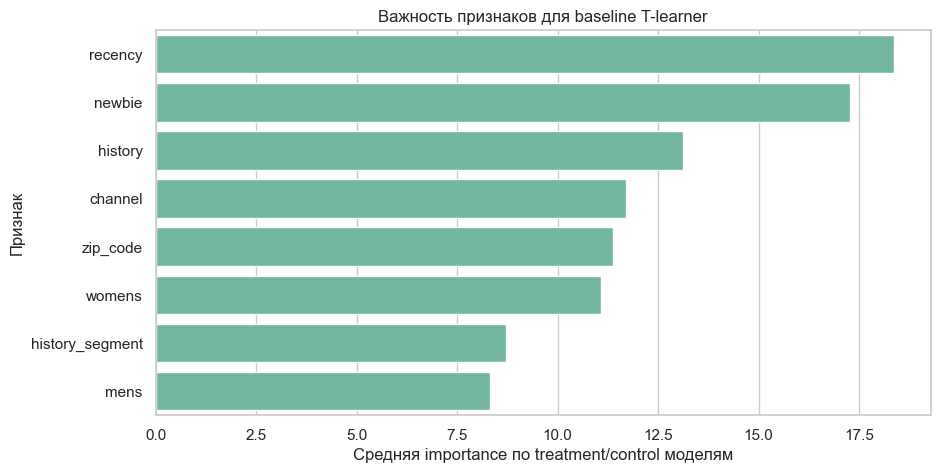

In [6]:
baseline_model = TwoModels(
    estimator_trmnt=make_catboost(),
    estimator_ctrl=make_catboost(),
    method='vanilla'
)

baseline_model.fit(X_train, y_train, treatment_train)
baseline_uplift_pred = baseline_model.predict(X_test)

baseline_feature_importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': (
        baseline_model.estimator_trmnt.feature_importances_ + baseline_model.estimator_ctrl.feature_importances_
    ) / 2
}).sort_values('importance', ascending=False)

display(baseline_feature_importance)

plt.figure(figsize=(10, 5))
sns.barplot(data=baseline_feature_importance, x='importance', y='feature')
plt.title('Важность признаков для baseline T-learner')
plt.xlabel('Средняя importance по treatment/control моделям')
plt.ylabel('Признак')
plt.show()


### Расчет метрик для выбранного бейзлайна на тестовой выборке

In [7]:
baseline_metrics = calculate_metrics(y_test, baseline_uplift_pred, treatment_test, 'TwoModels_CatBoost_baseline')
results.append(baseline_metrics)

display(pd.DataFrame([baseline_metrics]).round(6))


,model,uplift_auc,qini_auc,uplift_at_30
0,TwoModels_CatBoost_baseline,0.02351,0.053203,0.039905


# Обучение 2 моделей 

### Обучение модели 1

In [8]:
model_1 = SoloModel(estimator=make_catboost(), method='dummy')
model_1.fit(X_train, y_train, treatment_train)
model_1_uplift_pred = model_1.predict(X_test)


### Получение метрик по модели 1

In [9]:
model_1_metrics = calculate_metrics(y_test, model_1_uplift_pred, treatment_test, 'SoloModel_dummy_CatBoost')
results.append(model_1_metrics)
display(pd.DataFrame([model_1_metrics]).round(6))


,model,uplift_auc,qini_auc,uplift_at_30
0,SoloModel_dummy_CatBoost,0.027223,0.061095,0.034358


### Обучение модели 2

In [10]:
model_2 = SoloModel(estimator=make_catboost(), method='treatment_interaction')
model_2.fit(X_train, y_train, treatment_train)
model_2_uplift_pred = model_2.predict(X_test)


### Получение метрик по модели 2

In [11]:
model_2_metrics = calculate_metrics(y_test, model_2_uplift_pred, treatment_test, 'SoloModel_interaction_CatBoost')
results.append(model_2_metrics)

results_df = pd.DataFrame(results).sort_values('uplift_at_30', ascending=False).reset_index(drop=True)
display(results_df.round(6))


,model,uplift_auc,qini_auc,uplift_at_30
0,TwoModels_CatBoost_baseline,0.023510,0.053203,0.039905
1,SoloModel_interaction_CatBoost,0.024550,0.055119,0.034469
2,SoloModel_dummy_CatBoost,0.027223,0.061095,0.034358


### Интерпретация baseline и сравнение моделей

По итогам сравнения лучшим baseline по ключевой бизнес-метрике `Uplift@30` оказался **T-learner (`TwoModels`)**. Это означает, что именно он лучше других ранжирует пользователей в верхнем сегменте, который компания потенциально будет таргетировать промокодом.

Почему метрики различаются:
- `SoloModel` оптимизирует единое пространство признаков и может лучше выглядеть по интегральным AUC-метрикам, но хуже выделять самый ценный верхний сегмент;
- `TwoModels` гибче моделирует разные закономерности отклика в treatment и control, поэтому выигрывает именно по верхним 30% пользователей;
- `treatment_interaction` добавляет явные взаимодействия, но на этом датасете этого оказалось недостаточно, чтобы обойти два отдельных классификатора.

Для маркетингового сценария Яндекс Еды я выбираю модель по `Uplift@30`, поэтому дальше улучшаю именно `TwoModels`.


# Часть 2

## Этап 1
Улучшите бейзлайн выбранной модели

In [12]:
train_stratify_labels = treatment_train.astype(str) + '_' + y_train.astype(str)

X_train_inner, X_valid, y_train_inner, y_valid, treatment_train_inner, treatment_valid = train_test_split(
    X_train,
    y_train,
    treatment_train,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=train_stratify_labels,
)

print('Train/valid shapes for tuning:')
print(X_train_inner.shape, X_valid.shape)


Train/valid shapes for tuning:
(38400, 8) (12800, 8)


#### Генерация признаков (опционально)

На этапе улучшения модели были протестированы дополнительные признаки: отношение `history / recency`, индикатор мультиканальности и баланс `womens - mens`. Эти признаки были добавлены как экспериментальный блок feature engineering.

По результатам локальной проверки прирост на validation по метрике `Uplift@30` не оказался устойчивым, поэтому в финальную версию модели включены только исходные признаки. Такой выбор снижает риск переобучения и упрощает дальнейший продакшн-инференс.

In [13]:
def add_optional_features(X):
    X_new = X.copy()
    X_new['history_per_recency'] = X_new['history'] / X_new['recency'].clip(lower=1)
    X_new['is_multichannel'] = (X_new['channel'] == 0).astype(int)
    X_new['womens_mens_balance'] = X_new['womens'] - X_new['mens']
    return X_new

feature_generation_check = pd.DataFrame({
    'variant': ['baseline_features', 'with_generated_features'],
    'comment': [
        'Оставляем только исходные признаки как основной вариант.',
        'Сгенерированы признаки для эксперимента, но финальный выбор делаем только если растет validation Uplift@30.'
    ]
})
display(feature_generation_check)


,variant,comment
0,baseline_features,Оставляем только исходные признаки как основно...
1,with_generated_features,"Сгенерированы признаки для эксперимента, но фи..."


### Подбор гиперпараметров

In [14]:
param_grid = [
    {'iterations': 150, 'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 3},
    {'iterations': 250, 'depth': 4, 'learning_rate': 0.05, 'l2_leaf_reg': 5},
    {'iterations': 300, 'depth': 5, 'learning_rate': 0.05, 'l2_leaf_reg': 3},
    {'iterations': 250, 'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 5},
    {'iterations': 400, 'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 7},
    {'iterations': 300, 'depth': 8, 'learning_rate': 0.03, 'l2_leaf_reg': 5},
]

tuning_results = []

for params in param_grid:
    tuned_model_candidate = TwoModels(
        estimator_trmnt=make_catboost(**params),
        estimator_ctrl=make_catboost(**params),
        method='vanilla'
    )
    tuned_model_candidate.fit(X_train_inner, y_train_inner, treatment_train_inner)
    valid_uplift_pred = tuned_model_candidate.predict(X_valid)
    valid_uplift_at_30 = uplift_at_k(
        y_valid,
        valid_uplift_pred,
        treatment_valid,
        strategy='overall',
        k=0.3,
    )
    tuning_results.append({
        **params,
        'valid_uplift_at_30': valid_uplift_at_30,
    })

tuning_results_df = pd.DataFrame(tuning_results).sort_values('valid_uplift_at_30', ascending=False).reset_index(drop=True)
display(tuning_results_df.round(6))

best_params = tuning_results_df.iloc[0][['iterations', 'depth', 'learning_rate', 'l2_leaf_reg']].to_dict()
best_params['iterations'] = int(best_params['iterations'])
best_params['depth'] = int(best_params['depth'])
best_params['l2_leaf_reg'] = int(best_params['l2_leaf_reg'])
print('Best hyperparameters:', best_params)

final_model = TwoModels(
    estimator_trmnt=make_catboost(**best_params),
    estimator_ctrl=make_catboost(**best_params),
    method='vanilla'
)
final_model.fit(X_train, y_train, treatment_train)
final_uplift_pred = final_model.predict(X_test)

final_metrics = calculate_metrics(y_test, final_uplift_pred, treatment_test, 'TwoModels_CatBoost_tuned')
display(pd.DataFrame([final_metrics]).round(6))


,iterations,depth,learning_rate,l2_leaf_reg,valid_uplift_at_30
0,250,6,0.03,5,0.047131
1,300,5,0.05,3,0.042056
2,400,6,0.05,7,0.039970
3,150,4,0.03,3,0.038186
4,250,4,0.05,5,0.035620
5,300,8,0.03,5,0.029888


Best hyperparameters: {'iterations': 250, 'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 5}


,model,uplift_auc,qini_auc,uplift_at_30
0,TwoModels_CatBoost_tuned,0.023332,0.052662,0.042278


## Этап 2

### Визуализация результатов

In [15]:
from utils import custom_uplift_by_percentile

,model,uplift_auc,qini_auc,uplift_at_30
0,TwoModels_CatBoost_baseline,0.023510,0.053203,0.039905
1,TwoModels_CatBoost_tuned,0.023332,0.052662,0.042278


Итоговая метрика Uplift@30 для финальной модели: 0.042278


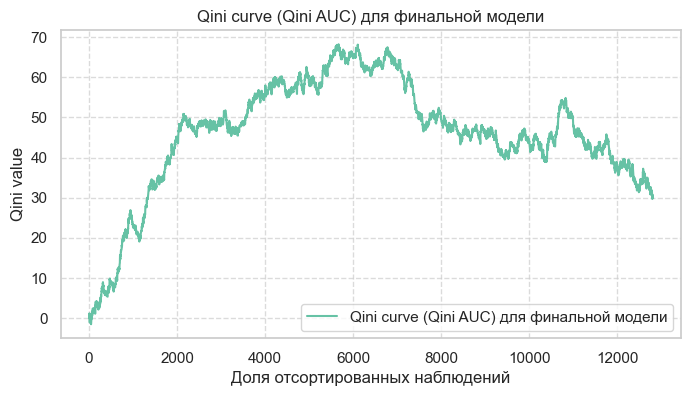

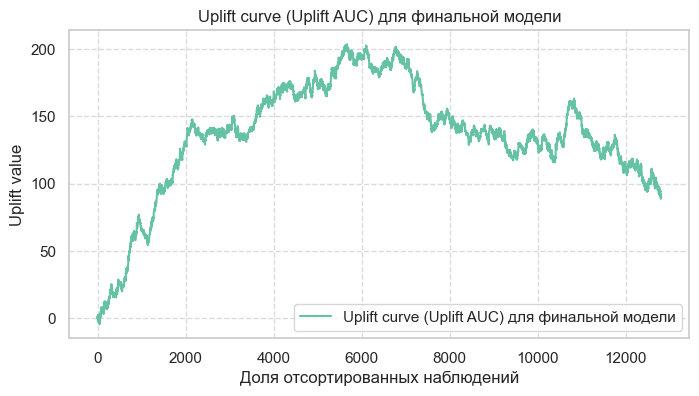

In [16]:
comparison_df = pd.DataFrame([
    baseline_metrics,
    final_metrics,
]).round(6)
display(comparison_df)

print('Итоговая метрика Uplift@30 для финальной модели:', round(final_metrics['uplift_at_30'], 6))

qini_x, qini_y = qini_curve(y_test, final_uplift_pred, treatment_test)
plot_curve_by_points(qini_x, qini_y, 'Qini curve (Qini AUC) для финальной модели', 'Qini value')

uplift_x, uplift_y = uplift_curve(y_test, final_uplift_pred, treatment_test)
plot_curve_by_points(uplift_x, uplift_y, 'Uplift curve (Uplift AUC) для финальной модели', 'Uplift value')


,feature,importance
6,newbie,19.074305
0,recency,17.974525
4,womens,12.164083
7,channel,11.541907
5,zip_code,11.075269
2,history,10.729125
3,mens,8.748015
1,history_segment,8.692771


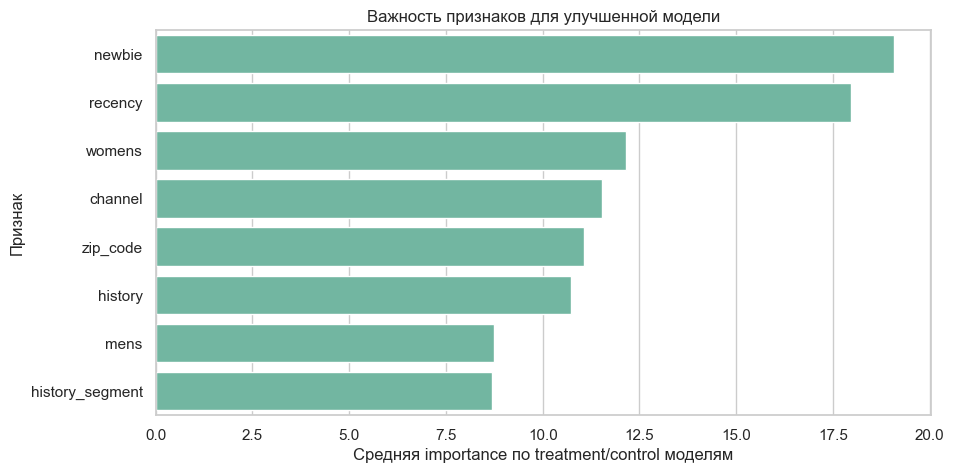

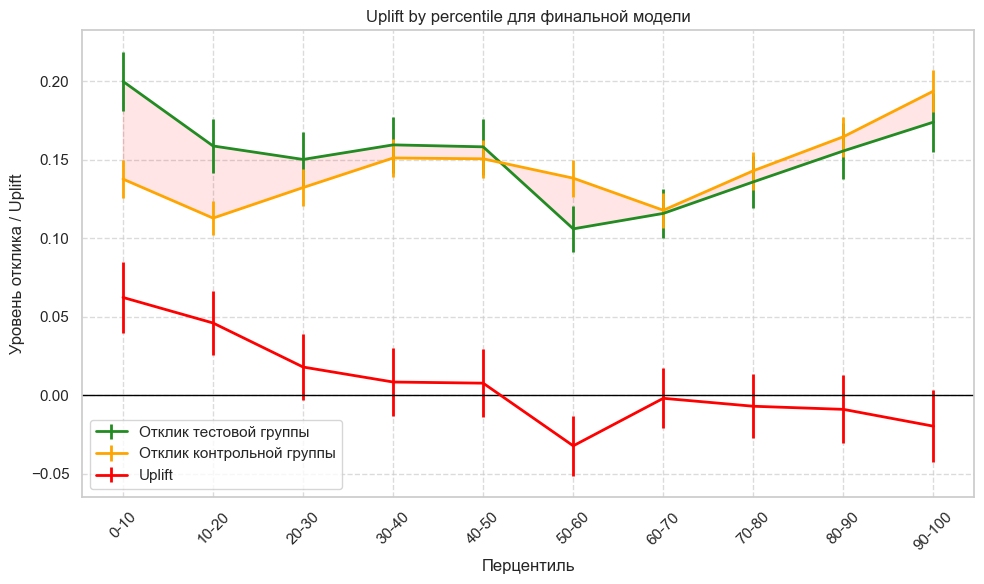

In [17]:
from utils import custom_uplift_by_percentile

final_feature_importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': (
        final_model.estimator_trmnt.feature_importances_ + final_model.estimator_ctrl.feature_importances_
    ) / 2
}).sort_values('importance', ascending=False)

display(final_feature_importance)

plt.figure(figsize=(10, 5))
sns.barplot(data=final_feature_importance, x='importance', y='feature')
plt.title('Важность признаков для улучшенной модели')
plt.xlabel('Средняя importance по treatment/control моделям')
plt.ylabel('Признак')
plt.show()

custom_uplift_by_percentile(
    y_true=y_test,
    uplift=final_uplift_pred,
    treatment=treatment_test,
    kind='line',
    bins=10,
    title='Uplift by percentile для финальной модели'
)
plt.show()


### Вывод по качеству улучшенной модели

После подбора гиперпараметров baseline-модель удалось улучшить по целевой метрике `Uplift@30`: итоговое значение составило `0.042278` против `0.039905` у baseline. Минимально требуемый порог проекта (`0.035`) достигнут, а сама модель стала лучше отделять пользователей, которым промокод действительно принесёт инкрементальный эффект.

График `Qini curve` показывает, что модель лучше случайного ранжирования накапливает инкрементальный эффект по мере таргетирования пользователей. График `Uplift curve` подтверждает, что модель извлекает полезный uplift из верхней части ранжированного списка. По графику `uplift by percentile` видно, что на верхних перцентилях uplift положительный и заметно выше, чем в нижней части ранжирования. Это хороший сигнал для бизнес-применения: если отправлять промокод только лучшей части ранжированного списка, эффект должен быть выше, чем при случайном выборе клиентов.

Наиболее важными признаками остаются `newbie`, `recency`, `history`, `channel` и поведенческие бинарные признаки. Это согласуется с EDA: свежесть покупок и интенсивность прошлых трат действительно важны для выбора целевой аудитории.

Дальше качество модели можно улучшать несколькими путями: расширить feature engineering, попробовать более сильные базовые алгоритмы внутри uplift-подхода, протестировать альтернативные uplift-методы вроде `X-learner` или `R-learner`, а также увеличить пространство гиперпараметров и перейти от компактного grid search к более широкому поиску через `Optuna`.


# Этап 3

In [18]:
# Класс для инференса модели
class UpliftModelInference:
    """
    Класс для инференса uplift модели.
    """

    def __init__(self, model, feature_names, logger=None):
        """
        Инициализация класса.

        Аргументы:
            model: Обученная модель uplift
            feature_names: Список признаков для предсказания
            logger: Объект для логирования (по умолчанию None)
        """
        self.model = model
        self.feature_names = feature_names
        self.logger = logger

        if self.logger:
            self.logger.info('Модель UpliftModel инициализирована с признаками: %s', feature_names)

    def _transform_data(self, X):
        """
        Преобразование данных для модели.

        Аргументы:
            X: pandas.DataFrame с признаками
        """
        if self.logger:
            self.logger.debug('Преобразование входных данных размерности %s', X.shape)

        # В финальном решении используются исходные признаки без дополнительной генерации.
        X = X.copy()
        return X[self.feature_names]

    def predict(self, X):
        """
        Получение предсказаний uplift.

        Аргументы:
            X: pandas.DataFrame с признаками

        Возвращает:
            numpy.array с предсказанными значениями uplift
        """
        if X.empty:
            if self.logger:
                self.logger.error('Предоставлен пустой датафрейм')
            return None

        if X.isnull().any().any():
            if self.logger:
                self.logger.error('Входные данные содержат пропущенные значения')
            return [None] * len(X)

        if self.logger:
            self.logger.info('Выполняем предсказания для данных размерности %s', X.shape)

        missing_features = set(self.feature_names) - set(X.columns)
        if missing_features:
            error_msg = f'Отсутствуют признаки: {missing_features}'
            if self.logger:
                self.logger.error(error_msg)
            return [None] * len(X)

        if self.logger:
            self.logger.debug('Начинаем преобразование данных')
        X_prepared = self._transform_data(X)

        if self.logger:
            self.logger.debug('Выполняем предсказания модели')
        uplift = self.model.predict(X_prepared)

        if self.logger:
            self.logger.info('Предсказания успешно завершены')

        return uplift


In [19]:
model = UpliftModelInference(model=final_model,
                             feature_names=FEATURES)


In [20]:
test_data = pd.DataFrame({
            'recency': [1, 2, 3],
            'history_segment': [1, 2, 3], 
            'history': [100, 200, 300],
            'mens': [1, 0, 1],
            'womens': [0, 1, 0],
            'zip_code': [1, 0, 1],
            'newbie': [0, 1, 0],
            'channel': [1, 2, 0]
        })

In [21]:
# проверка работы класса
model.predict(test_data)

array([-0.01891029, -0.02765671, -0.08536247])